In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os

# dataset_path = "/kaggle/input/deepfake-and-real-images"
# files = os.listdir(dataset_path)

# print(files)
# dataset_folder_path = os.path.join(dataset_path, 'Dataset')
# dataset_files = os.listdir(dataset_folder_path)

# print(dataset_files)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ismailpromus/skin-diseases-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/skin-diseases-image-dataset


In [3]:
import os

dataset_path = "/kaggle/input/skin-diseases-image-dataset"
files = os.listdir(dataset_path)

print(files)
img_classes_path = os.path.join(dataset_path, 'IMG_CLASSES')
img_classes_files = os.listdir(img_classes_path)
print(img_classes_files)


['IMG_CLASSES']
['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '4. Basal Cell Carcinoma (BCC) 3323', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '5. Melanocytic Nevi (NV) - 7970', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k', '3. Atopic Dermatitis - 1.25k', '6. Benign Keratosis-like Lesions (BKL) 2624', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '2. Melanoma 15.75k']


**Visualising the aspect ratios of each class**

1. Eczema 1677
10. Warts Molluscum and other Viral Infections - 2103
4. Basal Cell Carcinoma (BCC) 3323
7. Psoriasis pictures Lichen Planus and related diseases - 2k
5. Melanocytic Nevi (NV) - 7970
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k
3. Atopic Dermatitis - 1.25k
6. Benign Keratosis-like Lesions (BKL) 2624
8. Seborrheic Keratoses and other Benign Tumors - 1.8k
2. Melanoma 15.75k
[0.6625, 1.5254237288135593, 1.509433962264151, 1.5254237288135593, 1.5, 1.3243243243243243, 0.6625, 1.518987341772152, 0.6625, 1.5, 1.5254237288135593, 1.509433962264151, 1.3243243243243243, 1.5254237288135593, 1.5, 1.3243243243243243, 1.5, 0.6666666666666666, 1.5254237288135593, 1.5254237288135593, 1.5254237288135593, 1.5254237288135593, 1.5384615384615385, 1.5254237288135593, 1.5, 1.5254237288135593, 1.5, 1.5254237288135593, 1.5, 1.509433962264151, 1.5254237288135593, 1.509433962264151, 1.5254237288135593, 1.5254237288135593, 1.5, 0.8222222222222222, 1.509433962264151, 0.6625, 1.5

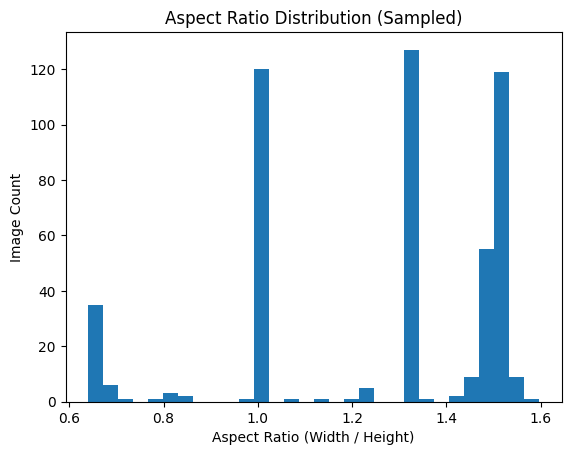

In [6]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = "/kaggle/input/skin-diseases-image-dataset"
sample_size_per_class = 50  
aspect_ratios = []
img_classes_path = os.path.join(dataset_path, 'IMG_CLASSES')
img_classes_files = os.listdir(img_classes_path)

for class_name in img_classes_files:
    print(class_name)
    class_dir = os.path.join(img_classes_path, class_name)

    if not os.path.isdir(class_dir): continue

    files = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

    sampled_files = random.sample(files, min(sample_size_per_class, len(files)))

    for file in sampled_files:
        img_path = os.path.join(class_dir, file)
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                aspect_ratios.append(w / h)
        except:
            continue
print(aspect_ratios)
# Visualize
plt.hist(aspect_ratios, bins=30)
plt.xlabel('Aspect Ratio (Width / Height)')
plt.ylabel('Image Count')
plt.title('Aspect Ratio Distribution (Sampled)')
plt.show()


**Splitting dataset using stratified split so each split preserves the label distribution**

In [7]:
import torch
from torch.utils.data import Subset
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split

dataset_root = "/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES"
full_dataset = ImageFolder(root=dataset_root) 


# Get all indices and labels
indices = list(range(len(full_dataset)))
labels = [full_dataset[i][1] for i in indices]

train_indices, temp_indices = train_test_split(
    indices, test_size=0.2, stratify=[labels[i] for i in indices], random_state=42)

val_indices, test_indices = train_test_split(
    temp_indices, test_size=0.5, stratify=[labels[i] for i in temp_indices], random_state=42)

train_subset = Subset(full_dataset, train_indices)
val_subset = Subset(full_dataset, val_indices)
test_subset = Subset(full_dataset, test_indices)

**Preprocessing**

In [9]:

from torchvision.transforms import functional as F

class PadToSquare:
    def __call__(self, img):
        w, h = img.size
        max_side = max(w, h)
        padding = (
            (max_side - w) // 2,  # left
            (max_side - h) // 2,  # top
            (max_side - w + 1) // 2,  # right
            (max_side - h + 1) // 2,  # bottom
        )
        return F.pad(img, padding, fill=0, padding_mode='constant')

In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader
import random
import torch

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# === Manual grouping based on class sizes ===
light_classes = [
    '2. Melanoma 15.75k',
    '4. Basal Cell Carcinoma (BCC) 3323',
    '5. Melanocytic Nevi (NV) - 7970'
]

moderate_classes = [
    '10. Warts Molluscum and other Viral Infections - 2103',
    '6. Benign Keratosis-like Lesions (BKL) 2624',
    '7. Psoriasis pictures Lichen Planus and related diseases - 2k'
]

strong_classes = [
    '1. Eczema 1677',
    '3. Atopic Dermatitis - 1.25k',
    '8. Seborrheic Keratoses and other Benign Tumors - 1.8k',
    '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k'
]

light_augmentation = transforms.Compose([
    PadToSquare(),
    transforms.Resize((380, 380)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

moderate_augmentation = transforms.Compose([
    PadToSquare(),
    transforms.Resize((380, 380)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

strong_augmentation = transforms.Compose([
    PadToSquare(),
    transforms.Resize((380, 380)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# base dataset w/o any transformation yet
base_dataset = ImageFolder(root=dataset_root, transform=None)

# all training samples 
train_samples = [base_dataset.samples[i] for i in train_subset.indices]

# downsampling the light classes as they have alot of imgs > thn the other classes , while keep the other classes the same 
balanced_samples = []
max_light_class_samples = 3000
for class_idx, class_name in enumerate(base_dataset.classes):
    class_samples = [s for s in train_samples if s[1] == class_idx]
    
    if class_name in light_classes and len(class_samples) > max_light_class_samples:
        class_samples = random.sample(class_samples, max_light_class_samples)
    
    balanced_samples.extend(class_samples)
# split into groups
light_samples = [s for s in balanced_samples if base_dataset.classes[s[1]] in light_classes]
moderate_samples = [s for s in balanced_samples if base_dataset.classes[s[1]] in moderate_classes]
strong_samples = [s for s in balanced_samples if base_dataset.classes[s[1]] in strong_classes]

# create respective datasets and apply the respective transformation
train_light = Subset(base_dataset, [base_dataset.samples.index(s) for s in light_samples])
train_light.dataset.transform = light_augmentation

train_moderate = Subset(base_dataset, [base_dataset.samples.index(s) for s in moderate_samples])
train_moderate.dataset.transform = moderate_augmentation

train_strong = Subset(base_dataset, [base_dataset.samples.index(s) for s in strong_samples])
train_strong.dataset.transform = strong_augmentation

# combine datasets
train_dataset = torch.utils.data.ConcatDataset([train_light, train_moderate, train_strong])

# dataloader for the train dataset
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)  # Use shuffle=True instead


In [12]:
import random
import torch

val_test_transform = transforms.Compose([
    PadToSquare(),
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])


base_val_test = ImageFolder(root=dataset_root, transform=val_test_transform)

val_dataset = Subset(base_val_test, val_subset.indices)
test_dataset = Subset(base_val_test, test_subset.indices)

# Create loaders
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

**Model**

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class EfficientNetWithLSTM(nn.Module):
    def __init__(self, hidden_dim=768, num_classes=10):
        super().__init__()

       
        self.backbone = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
        self.backbone.classifier = nn.Identity()  

        self.lstm = nn.LSTM(
            input_size=1792,  
            hidden_size=hidden_dim,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

        self.classifier = nn.Sequential(
            nn.BatchNorm1d(hidden_dim * 2),
            nn.Linear(hidden_dim * 2, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # x shape: [B, 3, 380, 380]
        feats = self.backbone.features(x)  # [B, 1792, H, W] 
        B, C, H, W = feats.size()
        feats = feats.view(B, C, -1).permute(0, 2, 1)  # [B, H*W, 1792] = [B, 144, 1792]

        lstm_out, _ = self.lstm(feats)  # [B, 144, 2*hidden_dim]
        pooled = lstm_out.mean(dim=1) 

        return self.classifier(pooled)
model = EfficientNetWithLSTM().to(device)






**Unfreezing, Freezing**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score

def freeze_everything_except_classifier(model):
    for name, param in model.named_parameters():
        if "backbone.features.7" in name or "lstm" in name or "classifier" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    print("Phase 1 - Unfreezing last block + LSTM + classifier")


def unfreeze_last_two_blocks(model):
    for name, param in model.named_parameters():
        if any(b in name for b in ["backbone.features.6", "backbone.features.7"]) or "lstm" in name or "classifier" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    print("Phase 3 - Unfreezing last two blocks")
def unfreeze_last_three_blocks(model):
    for name, param in model.named_parameters():
        if any(b in name for b in ["backbone.features.5", "backbone.features.6", "backbone.features.7"]) or "lstm" in name or "classifier" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    print("Phase 4 - Unfreezing last three blocks")

def unfreeze_last_four_blocks(model):
    for name, param in model.named_parameters():
        if any(b in name for b in ["backbone.features.4", "backbone.features.5", "backbone.features.6", "backbone.features.7"]) or "lstm" in name or "classifier" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    print("Phase 5 - Unfreezing last four blocks")



**Training**

In [ ]:
def train_model(model, train_loader, val_loader, device, criterion, total_epochs=15):
    from sklearn.metrics import f1_score
    phase_epochs = [5, 6, 7, 6]  
    phase_funcs = [
    freeze_everything_except_classifier,
    unfreeze_last_two_blocks,
    unfreeze_last_three_blocks,
    unfreeze_last_four_blocks
]

    lrs = [1e-3, 1e-4, 1e-5, 5e-6] 
   
    clf_lr = [1e-4, 5e-4,1e-3, 2.7e-3]
    for phase_idx, phase_func in enumerate(phase_funcs):
        phase_func(model)
        lr = lrs[phase_idx]
        lstm_lr_scale = 10 
        optimizer = torch.optim.Adam([
            {"params": model.backbone.parameters(), "lr": lr},
            {"params": model.lstm.parameters(), "lr": lr},
            {"params": model.classifier.parameters(), "lr": clf_lr[phase_idx]}             
        ])
        for epoch in range(phase_epochs[phase_idx]):
            model.train()
            running_loss = 0.0
            all_preds = []
            all_labels = []

            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())


            avg_loss = running_loss / len(train_loader)
            train_acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).sum().item() / len(all_labels)
            train_f1 = f1_score(all_labels, all_preds, average='macro')

 
            val_acc, val_f1 = evaluate_model(model, val_loader, device)

            print(f"Phase {phase_idx+1}, Epoch {epoch+1}/{phase_epochs[phase_idx]} | "
                  f"Train Loss: {avg_loss:.4f} | "
                  f"Train Acc: {train_acc:.2%} | Train F1: {train_f1:.4f} | "
                  f"Val Acc: {val_acc:.2%} | Val F1: {val_f1:.4f}")

   
            checkpoint_filename = f"efficientnet_phase{phase_idx+1}_epoch{epoch+1}.pth"
            torch.save(model.state_dict(), checkpoint_filename)
            print(f" Model saved as {checkpoint_filename}")


In [13]:
def evaluate_model(model, data_loader, device):
    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='macro')  # or 'weighted'
    return acc, f1


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from sklearn.utils.class_weight import compute_class_weight
targets = [s[1] for s in balanced_samples] 
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(base_dataset.classes)),
    y=targets
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
train_model(model, train_loader, val_loader, device, criterion, total_epochs=15)

**Grad-cam**

In [64]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import cv2
from torchvision.transforms.functional import to_pil_image, to_tensor, normalize

class GradCAM:
    def __init__(self, model):
        self.model = model
        self.model.eval()  
       
        self.target_layer = model.backbone.features[-1]
        self.gradients = None
        self.activations = None
        
        self.handles = []
        self.handles.append(self.target_layer.register_forward_hook(self.save_activation))
        self.handles.append(self.target_layer.register_full_backward_hook(self.save_gradient))
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def release(self):
        # Remove hooks when done
        for handle in self.handles:
            handle.remove()
    
    def __call__(self, x, class_idx=None):
        # store original model mode
        original_mode = self.model.training
        
        try:
            # switch to train mode (required for RNN backward pass)
            self.model.train()
            
            # disable BatchNorm tracking (since using batch_size=1)
            def set_bn_eval(module):
                if isinstance(module, torch.nn.modules.batchnorm._BatchNorm):
                    module.eval()
            self.model.apply(set_bn_eval)
            
            # enable gradients
            with torch.enable_grad():
                x.requires_grad_()  # enable gradients for input
                
                # forward pass through the whole model to get predictions
                model_output = self.model(x)
                
                if class_idx is None:
                    # use the predicted class if none is provided
                    class_idx = torch.argmax(model_output, dim=1).item()
                
                # create one-hot encoding for the target class
                one_hot = torch.zeros_like(model_output)
                one_hot[0, class_idx] = 1
                
                # zero gradients
                self.model.zero_grad()
                model_output.backward(gradient=one_hot, retain_graph=True)
                
                # Get weights
                # Global average pooling of gradients
                weights = torch.mean(self.gradients, dim=(2, 3))
                
                # Create class activation map
                batch_size, channels, height, width = self.activations.size()
                cam = torch.zeros(height, width, dtype=torch.float32, device=x.device)
                
                # Weight the channels by corresponding gradients
                for i, w in enumerate(weights[0]):
                    cam += w * self.activations[0, i, :, :]
                
                # Apply ReLU to focus on features that have a positive influence
                cam = F.relu(cam)
                # Normalize
                cam = cam - cam.min()
                if cam.max() > 0:
                    cam = cam / cam.max()
                # Resize to input image size
                cam = cam.unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
                cam = F.interpolate(cam, size=x.shape[2:], mode='bilinear', align_corners=False)
                cam = cam.squeeze()
            return cam.cpu().detach().numpy()
        
        finally:
            # Restore original model mode
            self.model.train(original_mode)

def visualize_gradcam(model, img_tensor, class_idx=None, class_names=None):

    # create Grad-CAM
    grad_cam = GradCAM(model)
    
    # get original image for display (before normalization)
    orig_img = img_tensor.squeeze().cpu().clone().detach()  
    
    # get prediction first (without gradients)
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_idx].item()
    
    
    target_idx = class_idx if class_idx is not None else pred_idx
    
    # Get class activation map (this will enable gradients internally)
    cam = grad_cam(img_tensor, target_idx)
    
    # Release hooks
    grad_cam.release()
    
    # Convert image tensor to numpy for visualization
    img_np = orig_img.permute(1, 2, 0).numpy() 
    
    # Normalize image to 0-1 range for display
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    
    # Create heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    
    # Resize heatmap to match image dimensions if needed
    if heatmap.shape[:2] != img_np.shape[:2]:
        heatmap = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
    
    # Overlay heatmap on original image
    result = 0.6 * img_np + 0.4 * heatmap
    result = result / result.max()
    
    # Create figure for visualization
    plt.figure(figsize=(15, 5))
    
    # Plot original image
    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title('Original Image')
    plt.axis('off')
    
    # Plot heatmap
    plt.subplot(1, 3, 2)
    plt.imshow(cam, cmap='jet')
    plt.title('Grad-CAM Heatmap')
    plt.axis('off')
    
    # Plot overlay
    plt.subplot(1, 3, 3)
    plt.imshow(result)
    
    # Add prediction info to title
    if class_names:
        title = f"Overlay\nPredicted: {class_names[pred_idx]} ({confidence:.2%})"
        if class_idx is not None and class_idx != pred_idx:
            title += f"\nTarget: {class_names[class_idx]}"
    else:
        title = f"Overlay\nPredicted: Class {pred_idx} ({confidence:.2%})"
        if class_idx is not None and class_idx != pred_idx:
            title += f"\nTarget: Class {class_idx}"
            
    plt.title(title)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

    return cam

In [ ]:
from torchvision.transforms.functional import to_pil_image
import matplotlib.pyplot as plt

class_names = base_val_test.classes
num_classes = len(class_names)

seen_classes = set()
images_per_class = {}

for inputs, labels in test_loader:
    for img, label in zip(inputs, labels):
        label = label.item()
        if label not in seen_classes:
            images_per_class[label] = img.unsqueeze(0).to(device)
            seen_classes.add(label)
        if len(seen_classes) == num_classes:
            break
    if len(seen_classes) == num_classes:
        break

In [ ]:
print("\n Visualizing with Grad-CAM:")

for label, img_tensor in images_per_class.items():
    # Run model prediction
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred].item()

    # Status
    status = "Correct" if pred == label else "Incorrect"
    print(f"\n{status} prediction")
    print(f"Predicted: {class_names[pred]} ({confidence:.2%})")
    print(f"Actual:    {class_names[label]}")

    # Grad-CAM for predicted class 
    print(f" Grad-CAM for predicted class: {class_names[pred]}")
    visualize_gradcam(model, img_tensor, class_idx=pred, class_names=class_names)
    #  Grad-CAM for true class if it was wrong
    # if pred != label:
    #     print(f"" Grad-CAM for actual class: {class_names[label]}")
    #     visualize_gradcam(model, img_tensor, class_idx=label, class_names=class_names)
